# implementation of boosting adaboost and gradiant boost

#import section


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import AdaBoostClassifier,GradientBoostingClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [ ]:
data =pd.read_csv("diabetes.csv")

In [ ]:
print(type(data))
#print(data.describe)
print(len(data.columns))

<class 'pandas.core.frame.DataFrame'>
9


In [ ]:
x=data.drop('Outcome',axis=1)
x1=x
print(x.columns)
y=data['Outcome']
print(y)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')
0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


#normalize

In [ ]:
scaler=StandardScaler()
x=scaler.fit_transform(x)

#train test split

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


#train the model

In [ ]:
model=AdaBoostClassifier(
                        n_estimators=50,
                         random_state=42
                         )
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(f'accracy score : {accuracy_score(y_test,y_pred)}')

accracy score : 0.7792207792207793


In [ ]:
model=AdaBoostClassifier(
                        n_estimators=10,
                         random_state=42
                         )
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(f'accracy score : {accuracy_score(y_test,y_pred)}')

accracy score : 0.7597402597402597


In [ ]:
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[83 16]
 [21 34]]
              precision    recall  f1-score   support

           0       0.80      0.84      0.82        99
           1       0.68      0.62      0.65        55

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.76      0.76       154



#gradiant boosting

In [ ]:
model=GradientBoostingClassifier(
                                n_estimators=50,
                                 learning_rate=0.1
                                 )
model.fit(x_train,y_train)
y_pred_grad=model.predict(x_test)

In [ ]:
print(f'accuracy score: {accuracy_score(y_test,y_pred_grad)}')

accuracy score: 0.7662337662337663


In [ ]:
print(f'confusion matrix : {confusion_matrix(y_test,y_pred_grad)}')


confusion matrix : [[79 20]
 [16 39]]


In [ ]:
print(classification_report(y_test,y_pred_grad))

              precision    recall  f1-score   support

           0       0.83      0.80      0.81        99
           1       0.66      0.71      0.68        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



In [ ]:
print(model.feature_importances_)

[0.01640555 0.43199081 0.03745146 0.01613553 0.05014702 0.19078086
 0.09240414 0.16468463]


<BarContainer object of 8 artists>

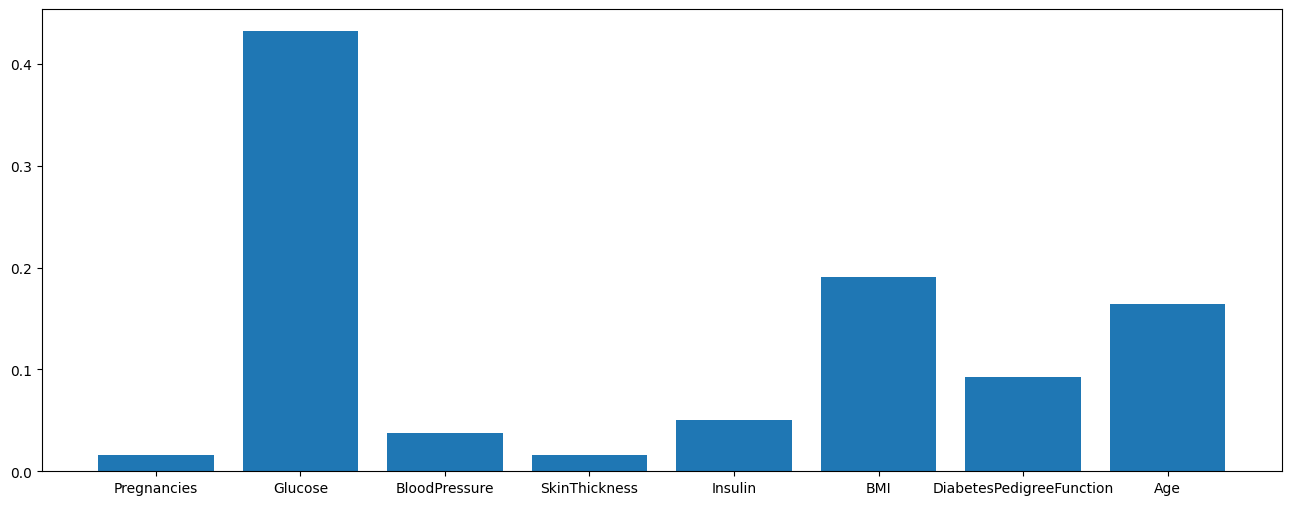

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(16,6))
y_axis=np.arange(0,50)
#print(y_axis)
plt.bar(x1.columns,model.feature_importances_)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
model=DecisionTreeClassifier()
model.fit(x_train,y_train)
p=model.predict(x_test)
print(f'accuracy score: {accuracy_score(y_test,p)}')

accuracy score: 0.7337662337662337
